## Environment Setup

In [168]:
import os, kagglehub, time, joblib
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score

- Check point code: [DICKY SAPUTRA](https://colab.research.google.com/drive/1FihQmxGLMqx9oZnmBDzlihmFXn-RBU5K?usp=sharing)
- Dataset: [Source](https://www.kaggle.com/datasets/wisnuanggara/daftar-harga-rumah)

## 1. Business Understanding

### 1.1 Define the Problem

Dalam industri properti, menentukan harga jual sebuah rumah secara akurat adalah tantangan besar. Harga yang terlalu tinggi akan membuat properti sulit terjual, sedangkan harga yang terlalu rendah akan merugikan pemilik atau pengembang. Masalah utamanya adalah: **"Bagaimana kita bisa memprediksi harga pasar sebuah rumah secara objektif berdasarkan spesifikasi fisiknya (luas tanah, luas bangunan, jumlah kamar, dll) agar tidak terjadi kesalahan penetapan harga?"**

### 1.2 Set Objectives

Tujuan teknis dari proyek data mining ini adalah:

* Membangun model prediktif yang dapat mengestimasi harga rumah berdasarkan fitur-fitur yang tersedia di dataset.
* Membandingkan tiga algoritma regresi (**Linear Regression, Random Forest Regressor, dan Gradient Boosting Regressor**) untuk menemukan model yang paling cocok dengan karakteristik data rumah ini.
* Meminimalkan tingkat kesalahan prediksi agar selisih antara harga prediksi dan harga asli sekecil mungkin.

### 1.3 Identify Stakeholders

Pihak-pihak yang berkepentingan dan manfaat yang mereka harapkan adalah:

* **Agen Properti/Developer:** Mendapatkan referensi harga jual yang kompetitif untuk proyek baru atau listing rumah.
* **Calon Pembeli:** Memastikan mereka membayar harga yang wajar sesuai dengan spesifikasi bangunan yang didapatkan.
* **Tim Data Analyst:** Memberikan rekomendasi model machine learning yang paling stabil dan akurat untuk digunakan dalam jangka panjang.

### 1.4 Define Success Criteria

Keberhasilan proyek ini diukur berdasarkan dua kriteria:

* **Kriteria Teknis:** Model dianggap sukses jika menghasilkan skor **MAPE (Mean Absolute Percentage Error)** yang paling rendah di antara ketiga model yang diuji. Targetnya adalah mendapatkan rata-rata persentase error yang bisa ditoleransi oleh pasar (misalnya di bawah 5%).
* **Kriteria Bisnis:** Terpilihnya satu model terbaik yang memberikan keseimbangan antara akurasi dan kemudahan interpretasi, yang nantinya dapat digunakan sebagai alat bantu hitung (kalkulator) harga rumah otomatis.

## 2. Data Understanding

### 2.1. Collect Data

In [169]:
path = kagglehub.dataset_download("wisnuanggara/daftar-harga-rumah")
print(f"Dataset: {os.listdir(path)}")

df = pd.read_excel(os.path.join(path, "DATA RUMAH.xlsx"))

Dataset: ['DATA RUMAH.xlsx', 'HARGA RUMAH JAKSEL.xlsx']


### 2.2. Describe Data

In [170]:
print("--- Informasi Struktur Data ---")
df.info()

--- Informasi Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   NO          1010 non-null   int64 
 1   NAMA RUMAH  1010 non-null   object
 2   HARGA       1010 non-null   int64 
 3   LB          1010 non-null   int64 
 4   LT          1010 non-null   int64 
 5   KT          1010 non-null   int64 
 6   KM          1010 non-null   int64 
 7   GRS         1010 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 63.3+ KB


* **Struktur Data:** Dataset memiliki **1010 entri** tanpa ada *missing values* (data kosong) pada semua kolom. Ini adalah awal yang sangat baik.
* **Variabel:** Terdapat 7 fitur numerik dan 1 fitur kategorikal (`NAMA RUMAH`). Kolom `NO` dan `NAMA RUMAH` teridentifikasi sebagai fitur yang tidak memiliki nilai prediktif untuk harga.

In [171]:
print("-- Statistik Deskriptif ---")
display(df.describe())

-- Statistik Deskriptif ---


,NO,HARGA,LB,LT,KT,KM,GRS
count,1010.000000,1.010000e+03,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000
mean,505.500000,7.628987e+09,276.539604,237.432673,4.668317,3.607921,1.920792
std,291.706188,7.340946e+09,177.864557,179.957604,1.572776,1.420066,1.510998
min,1.000000,4.300000e+08,40.000000,25.000000,2.000000,1.000000,0.000000
25%,253.250000,3.262500e+09,150.000000,130.000000,4.000000,3.000000,1.000000
50%,505.500000,5.000000e+09,216.500000,165.000000,4.000000,3.000000,2.000000
75%,757.750000,9.000000e+09,350.000000,290.000000,5.000000,4.000000,2.000000
max,1010.000000,6.500000e+10,1126.000000,1400.000000,10.000000,10.000000,10.000000


* **Rentang Harga:** Harga rumah memiliki variasi yang sangat ekstrem, mulai dari **Rp430 Juta hingga Rp65 Miliar**, dengan rata-rata di angka **Rp7,6 Miliar**.

In [172]:
print("--- Tipe Data ---")
print(df.dtypes)

--- Tipe Data ---
NO             int64
NAMA RUMAH    object
HARGA          int64
LB             int64
LT             int64
KT             int64
KM             int64
GRS            int64
dtype: object


### 2.3. Explore Data (EDA)

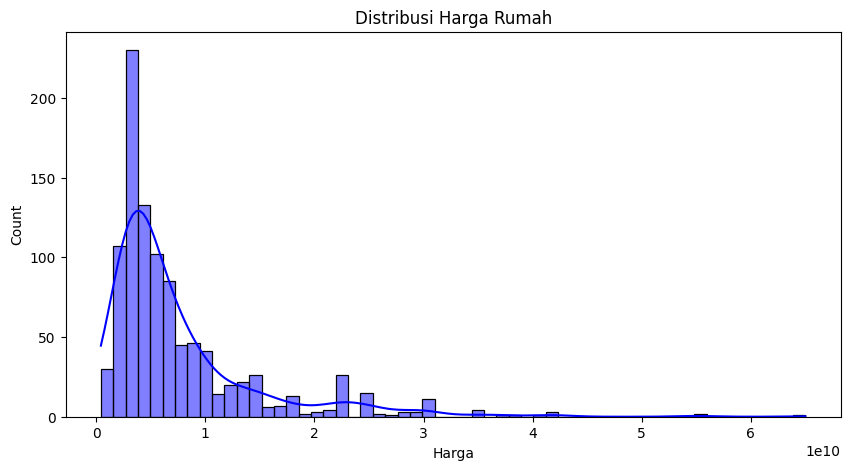

In [173]:
# 1. Visualisasi Distribusi Target (Harga)
plt.figure(figsize=(10, 5))
sns.histplot(df['HARGA'], kde=True, color='blue')
plt.title('Distribusi Harga Rumah')
plt.xlabel('Harga')
plt.show()

**Distribusi Harga (Histogram):** Data memiliki distribusi **Positive Skew** (menceng ke kanan). Artinya, mayoritas rumah berada di harga "rendah" (di bawah Rp10 Miliar), namun ada beberapa rumah "Sultan" yang harganya sangat tinggi yang menarik rata-rata ke atas.

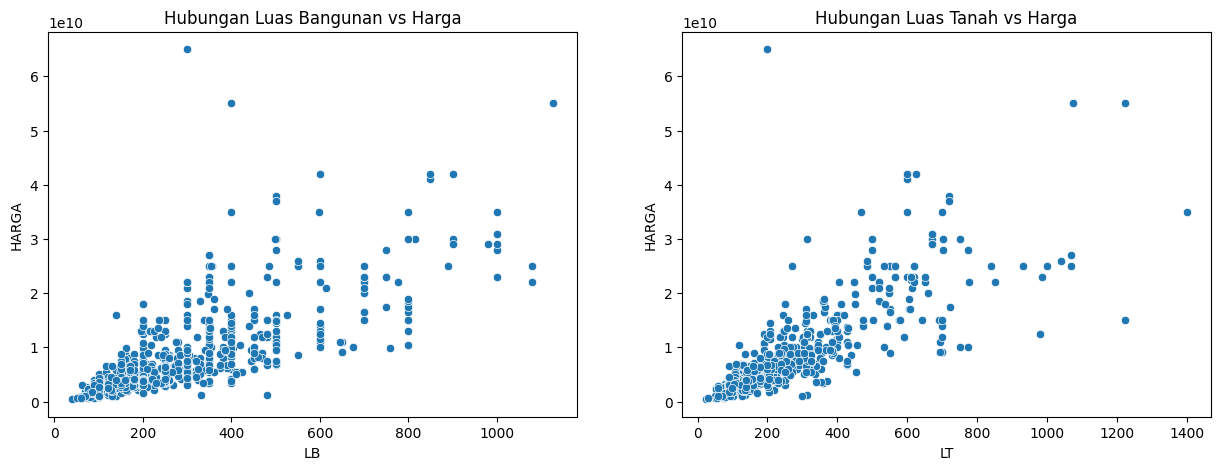

In [174]:
# 2. Scatter Plot untuk melihat hubungan LT/LB dengan Harga
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x='LB', y='HARGA', ax=ax[0])
ax[0].set_title('Hubungan Luas Bangunan vs Harga')

sns.scatterplot(data=df, x='LT', y='HARGA', ax=ax[1])
ax[1].set_title('Hubungan Luas Tanah vs Harga')
plt.show()

**Hubungan LB & LT terhadap Harga (Scatter Plot):** Terlihat korelasi linear yang positif. Semakin besar Luas Bangunan (LB) dan Luas Tanah (LT), semakin tinggi harganya. Namun, terdapat titik-titik yang menyebar jauh dari garis tren utama (terutama pada LB > 600), yang menunjukkan adanya faktor lain selain luas lahan yang menentukan harga.

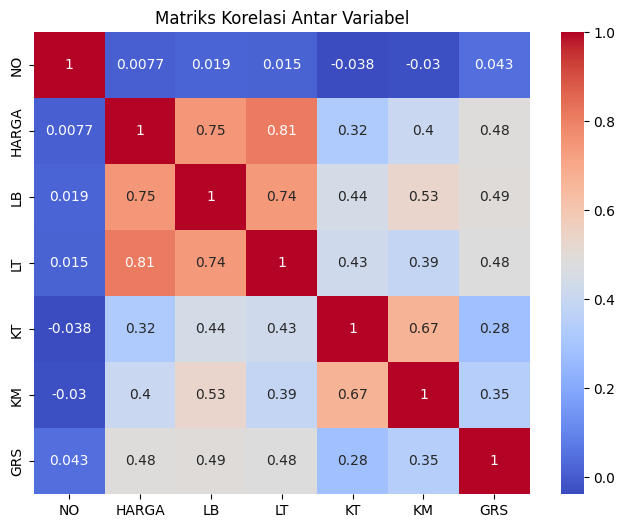

In [175]:
# 3. Heatmap Korelasi untuk melihat variabel mana yang paling berpengaruh
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm')
plt.title('Matriks Korelasi Antar Variabel')
plt.show()

* **Kekuatan Hubungan (Heatmap Korelasi):** * **Luas Tanah (LT)** adalah faktor penentu terkuat dengan nilai korelasi **0.81**.
* **Luas Bangunan (LB)** mengikuti di posisi kedua dengan nilai **0.75**.
* Jumlah kamar (`KT`, `KM`) memiliki korelasi yang lebih rendah (0.3 - 0.4), menunjukkan bahwa luas lahan jauh lebih dihargai daripada sekadar jumlah ruangan.

### 2.4. Verify Data Quality

In [176]:
# 1. Dasar: Missing Values & Duplicates
print(f"Jumlah Missing Values:\n{df.isnull().sum()}")
print(f"\nJumlah Data Duplikat: {df.duplicated().sum()}")

Jumlah Missing Values:
NO            0
NAMA RUMAH    0
HARGA         0
LB            0
LT            0
KT            0
KM            0
GRS           0
dtype: int64

Jumlah Data Duplikat: 0


**Kualitas Data:** Tidak ditemukan data duplikat atau nilai nol pada kolom penting, sehingga data secara teknis cukup bersih.

In [177]:
# 2. Logical Consistency Check
# Mengecek apakah ada data yang tidak masuk akal secara logika properti
print("--- 2. Logical Consistency Check ---")
anomali_lb_lt = df[df['LB'] > df['LT'] * 3] # Contoh: Bangunan 3x lebih luas dari tanah (mungkin typo)
anomali_harga = df[df['HARGA'] <= 0]
anomali_kamar = df[(df['KT'] == 0) | (df['KM'] == 0)]

print(f"Jumlah baris dengan LB > 3x LT: {len(anomali_lb_lt)}")
print(f"Jumlah rumah dengan Harga <= 0: {len(anomali_harga)}")
print(f"Jumlah rumah tanpa Kamar Tidur/Mandi: {len(anomali_kamar)}")

--- 2. Logical Consistency Check ---
Jumlah baris dengan LB > 3x LT: 3
Jumlah rumah dengan Harga <= 0: 0
Jumlah rumah tanpa Kamar Tidur/Mandi: 0


**Temuan Anomali Logika:**
* Terdapat **3 baris** di mana Luas Bangunan (LB) lebih dari 3 kali lipat Luas Tanah (LT). Meskipun bangunan bertingkat memungkinkan hal ini, rasio > 3x perlu diwaspadai sebagai potensi kesalahan input data.
* Tidak ditemukan harga nol atau negatif, serta tidak ada rumah tanpa kamar, sehingga data secara fungsional sangat bersih.

In [178]:
# Mengambil 3 baris yang terdeteksi anomali
anomali_data = df[df['LB'] > df['LT'] * 3]

display(anomali_data[['NAMA RUMAH', 'HARGA', 'LB', 'LT', 'KT', 'KM']])

,NAMA RUMAH,HARGA,LB,LT,KT,KM
453,Rumah Dijual di Tebet Jakarta Selatan,3500000000,350,100,4,4
468,Dijual Rumah Siap Huni di Tebet Jakarta Selatan,3500000000,350,100,4,4
498,Rumah Mewah Brand New Di Menteng Dalam Tebet J...,25000000000,890,271,5,6


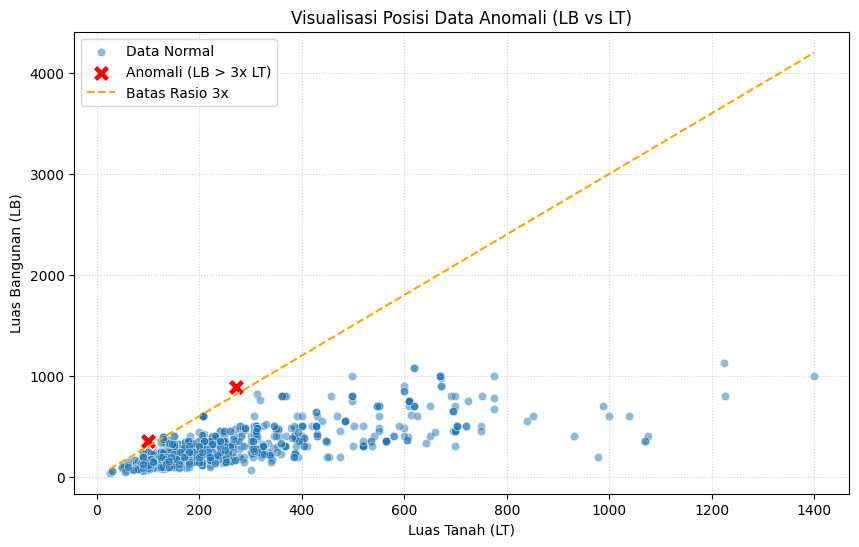

In [179]:
plt.figure(figsize=(10, 6))

# Plot data normal
sns.scatterplot(data=df, x='LT', y='LB', alpha=0.5, label='Data Normal')

# Highlight data anomali dengan warna merah dan simbol X
sns.scatterplot(data=anomali_data, x='LT', y='LB', color='red', s=150, label='Anomali (LB > 3x LT)', marker='X')

# Tambahkan garis batas (LB = 3 * LT) sebagai referensi visual
lt_range = np.linspace(df['LT'].min(), df['LT'].max(), 100)
plt.plot(lt_range, 3 * lt_range, color='orange', linestyle='--', label='Batas Rasio 3x')

plt.title('Visualisasi Posisi Data Anomali (LB vs LT)')
plt.xlabel('Luas Tanah (LT)')
plt.ylabel('Luas Bangunan (LB)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [180]:
# Menentukan kolom teknis yang seharusnya unik untuk satu properti
kolom_teknis = ['HARGA', 'LB', 'LT', 'KT', 'KM', 'GRS']

# Mengecek duplikasi hanya berdasarkan kolom teknis
duplikat_teknis = df[df.duplicated(subset=kolom_teknis, keep=False)]

print(f"Jumlah baris dengan konten teknis identik: {len(duplikat_teknis)}")

Jumlah baris dengan konten teknis identik: 81


In [181]:
print("--- Detail Baris yang Memiliki Konten Identik ---")
display(duplikat_teknis.sort_values(by='HARGA'))

--- Detail Baris yang Memiliki Konten Identik ---


,NO,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS
315,316,Rumah Bagus Murah Sekali Cocok Utk Tempat Ting...,1500000000,200,170,7,2,0
755,756,Di Jual Rumah Murah Di Tebet,1500000000,200,170,7,2,0
995,996,Rumah Murah Sekali Siap Huni Akses Gg 2 Motor ...,1500000000,200,170,7,2,0
392,393,Rumah Siap Huni Hanya 50m Dari Dan Ke Asem Bar...,2100000000,100,126,2,2,1
989,990,Rumah Siap Huni Hanya 50meter Ke Jalan Asembar...,2100000000,100,126,2,2,1
...,...,...,...,...,...,...,...,...
324,325,Dijual Rumah Second Strategis Tanah Luas di Tebet,23000000000,350,565,5,3,4
409,410,Rumah Second Terawat Dan Setrategis Tebet Jaka...,23000000000,350,565,5,3,4
54,55,"Rumah di tebet, Jakarta Selatan, dekat tol, Te...",23000000000,750,610,8,6,4
282,283,Dijual Rumah Secondary Luas di tebent Lokasi S...,23000000000,350,565,5,3,4


C:\Users\Administrator\AppData\Local\Temp\ipykernel_33992\813739438.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_duplicates.index, y=top_duplicates.values, palette='viridis')


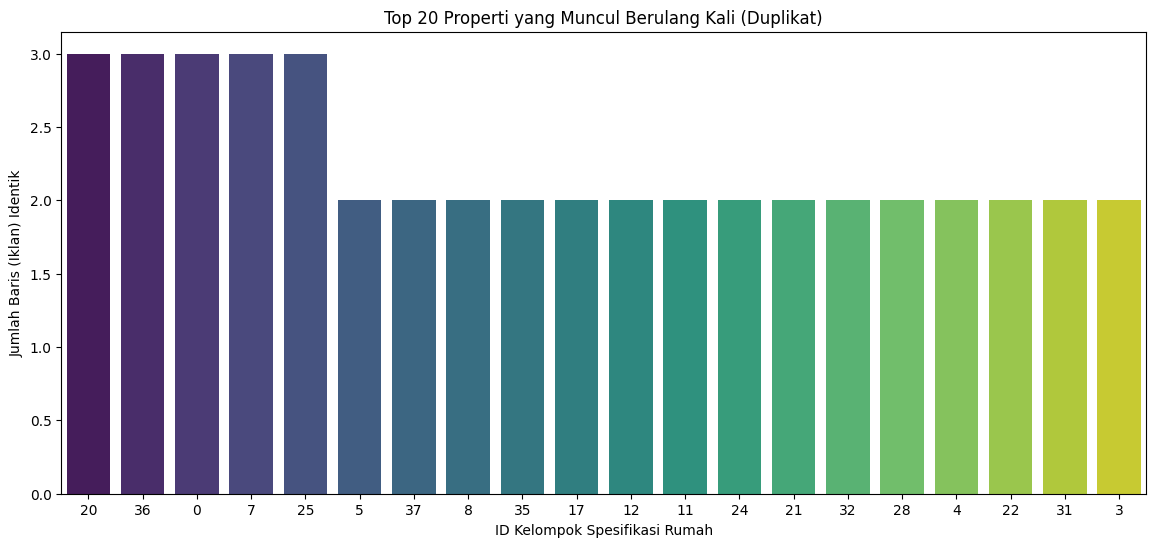

In [182]:
# 1. Identifikasi data duplikat berdasarkan fitur teknis saja
kolom_teknis = ['HARGA', 'LB', 'LT', 'KT', 'KM', 'GRS']
df_duplikat = df[df.duplicated(subset=kolom_teknis, keep=False)].copy()

# 2. Membuat ID unik untuk setiap kelompok spesifikasi yang sama
df_duplikat['Spec_ID'] = df_duplikat.groupby(kolom_teknis).ngroup().astype(str)

# Visualisasi 1: Frekuensi Kemunculan Properti yang Sama
plt.figure(figsize=(14, 6))
top_duplicates = df_duplikat['Spec_ID'].value_counts().head(20)
sns.barplot(x=top_duplicates.index, y=top_duplicates.values, palette='viridis')
plt.title('Top 20 Properti yang Muncul Berulang Kali (Duplikat)')
plt.xlabel('ID Kelompok Spesifikasi Rumah')
plt.ylabel('Jumlah Baris (Iklan) Identik')
plt.show()

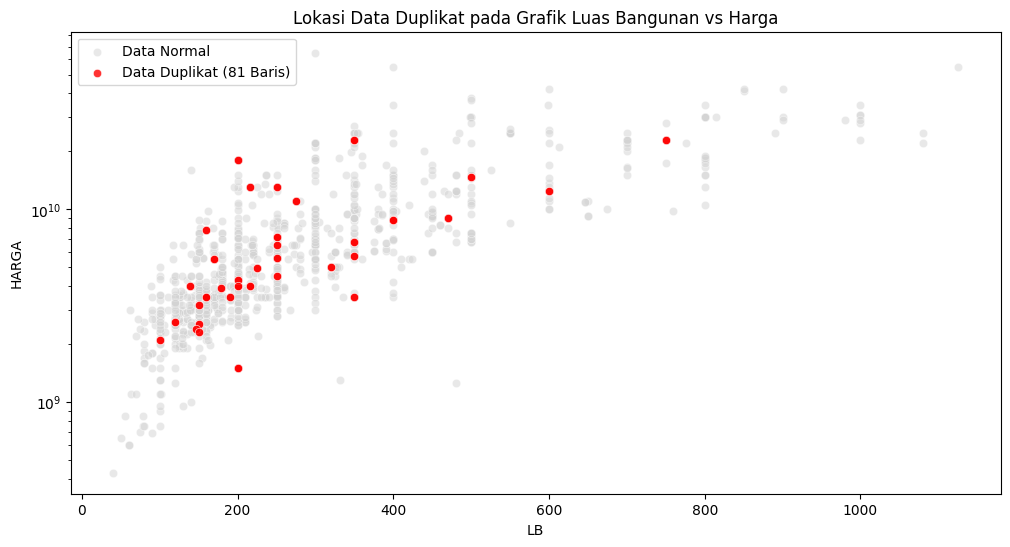

In [183]:
# Visualisasi 2: Di mana posisi 81 data duplikat ini dalam distribusi pasar?
plt.figure(figsize=(12, 6))
# Plot semua data sebagai background
sns.scatterplot(data=df, x='LB', y='HARGA', color='lightgrey', alpha=0.5, label='Data Normal')
# Highlight data duplikat
sns.scatterplot(data=df_duplikat, x='LB', y='HARGA', color='red', alpha=0.8, label='Data Duplikat (81 Baris)')

plt.title('Lokasi Data Duplikat pada Grafik Luas Bangunan vs Harga')
plt.yscale('log') # Skala logaritma agar harga puluhan miliar tidak menumpuk di atas
plt.legend()
plt.show()

In [184]:
# 3. Multicollinearity Check menggunakan VIF
print("--- 3. Multicollinearity Check (VIF) ---")
# Kita hanya mengecek variabel numerik yang akan jadi fitur (X)
X_vif = df[['LB', 'LT', 'KT', 'KM', 'GRS']]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

--- 3. Multicollinearity Check (VIF) ---
  Feature        VIF
3      KM  15.218643
2      KT  13.853002
0      LB   9.199820
1      LT   6.596529
4     GRS   3.618200


**Apa itu VIF?**
VIF (Variance Inflation Factor) adalah skor yang menunjukkan seberapa besar sebuah fitur "didikte" oleh fitur lainnya.

* **Skor > 10:** Menandakan fitur tersebut sangat berkorelasi dengan fitur lain (Redundan).
* **Skor < 10:** Menandakan fitur masih membawa informasi unik yang cukup.

**Analisis Hasil:**

1. **KM (15.21) & KT (13.85):** Memiliki skor tertinggi. Ini wajar karena jumlah Kamar Mandi biasanya mengikuti jumlah Kamar Tidur. Secara teknis, ini bisa membingungkan model **Linear Regression** dalam menentukan pengaruh masing-masing terhadap harga.
2. **LB (9.19) & LT (6.59):** Berada di area aman/moderat. Luas Bangunan dan Luas Tanah adalah penggerak utama harga, namun keduanya tidak saling "menjiplak" secara ekstrem.

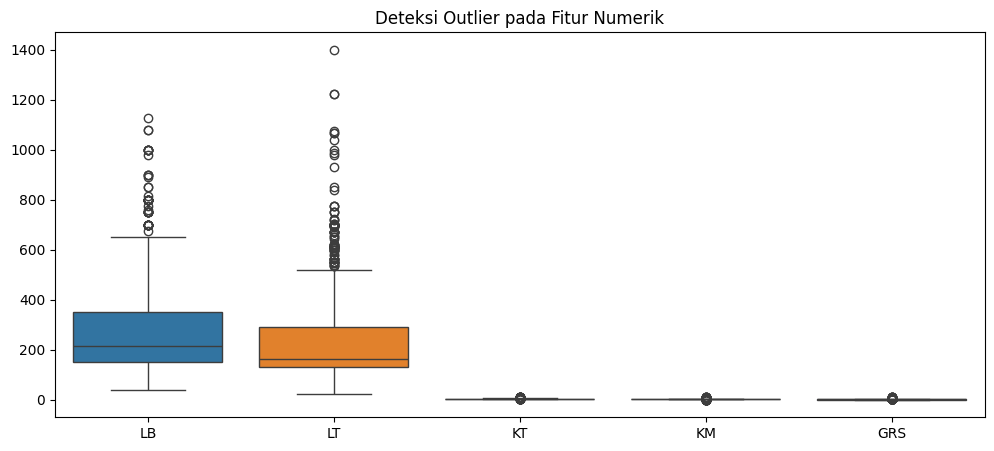

In [185]:
# 4. Outlier Analysis (Visual)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[['LB', 'LT', 'KT', 'KM', 'GRS']])
plt.title('Deteksi Outlier pada Fitur Numerik')
plt.show()

* **Analisis Outlier (Boxplot):** Ini adalah bagian terpenting. Terdapat banyak sekali **outlier** pada variabel `LB` dan `LT`.
    * Ada rumah dengan luas tanah mencapai 1400 m^2, sementara rata-ratanya hanya 237 m^2.
    * **Dampaknya pada MAPE:** Outlier-outlier ini (rumah yang sangat besar/mahal) biasanya akan menghasilkan error yang besar pada model machine learning. Jika kita ingin mengejar target MAPE < 5%, kita harus memutuskan di tahap *Data Preparation* nanti apakah outlier ini akan dihapus atau dilakukan *scaling* khusus.

### INSIGHT & CONCULSION

1. Seleksi dan Pembersihan Data (Data Cleaning)
    * **Penghapusan Duplikasi Teknis (81 Baris):** Kita akan menghapus duplikat berdasarkan *subset* fitur teknis (`HARGA`, `LB`, `LT`, `KT`, `KM`, `GRS`). Ini krusial karena duplikasi ini sebenarnya adalah objek properti yang sama yang diiklankan berulang kali.
    * **Penanganan Anomali (LB > 3x LT):** Kita memutuskan untuk **tetap mempertahankan** 3 data ini. Meskipun secara statistik merupakan pencilan, secara realitas bisnis di Jakarta Selatan (Tebet/Menteng), rumah 3 lantai pada lahan sempit adalah valid.
    * **Drop Fitur Non-Prediktif:** Menghapus kolom `NO` (hanya indeks) dan `NAMA RUMAH` (teks tidak terstruktur) agar model fokus sepenuhnya pada variabel numerik.

2. Rekayasa Fitur (Feature Engineering)
    * **Transformasi Logaritma (Log Transformation):** Ini adalah strategi **paling penting** untuk mencapai MAPE rendah. Kita akan menerapkan fungsi log(x) pada kolom `HARGA`, `LB`, dan `LT`.
        * **Alasannya:** Harga rumah memiliki rentang sangat ekstrem (Ratusan Juta vs Puluhan Miliar). Log transformasi akan menormalkan distribusi dan mencegah model didominasi oleh rumah-rumah "Sultan".
    * **Menangani Multikolinieritas:** Karena VIF pada `KM` dan `KT` > 10, kita mendapatkan konfirmasi bahwa fitur ini saling tumpang tindih. Kita akan membiarkannya untuk model **Random Forest** dan **Gradient Boosting** (yang tahan multikolinieritas), namun ini menjadi catatan kenapa **Linear Regression** mungkin tertinggal akurasinya.

3. Penyesuaian Format (Data Formatting)
    * **Train-Test Split (80:20):** Membagi data menjadi 80% untuk melatih model dan 20% untuk pengujian objektif.
    * **Standardization/Scaling:** Jika diperlukan (terutama untuk Linear Regression), kita akan melakukan penskalaan agar semua fitur memiliki rentang nilai yang seragam.

Ringkasan Tindakan (Checklist):

| Masalah | Tindakan Preparation |
| --- | --- |
| **81 Duplikat Iklan** | `drop_duplicates(subset=['HARGA', 'LB', ...])` |
| **Rentang Harga Lebar** | `np.log1p()` pada Harga, LB, dan LT |
| **VIF Tinggi (KM/KT)** | Gunakan model berbasis Tree (RF/GBR) |
| **Data Noise (NO, Nama)** | `df.drop(columns=['NO', 'NAMA RUMAH'])` |

## 3. Data Preparation

### 3.1. Data Selection

* **Feature Selection:** Kita membuang `NO` dan `NAMA RUMAH`. Kolom `NO` hanyalah urutan angka, dan `NAMA RUMAH` adalah teks deskriptif yang terlalu bervariasi untuk model regresi sederhana. Kita ingin model fokus pada angka-angka fisik bangunan.
* **Row Selection:** Kita menggunakan `subset=kolom_teknis` untuk menghapus 81 iklan duplikat yang kita temukan tadi. Dengan menyisakan hanya satu baris unik untuk setiap properti, model akan belajar dari data yang lebih jujur dan tidak terdistorsi oleh iklan yang berulang.

In [186]:
# 1. Feature Selection
# Menghapus kolom 'NO' dan 'NAMA RUMAH' karena tidak memiliki pengaruh statistik terhadap harga
df_selected = df.drop(columns=['NO', 'NAMA RUMAH'])

In [187]:
# 2. Row Selection (Handling Duplicates)
# Menentukan kolom teknis yang digunakan sebagai acuan duplikasi
kolom_teknis = ['HARGA', 'LB', 'LT', 'KT', 'KM', 'GRS']

# Menghapus 81 baris duplikat teknis dan hanya menyisakan satu baris pertama (keep='first')
df_cleaned = df_selected.drop_duplicates(subset=kolom_teknis, keep='first')

In [188]:
# 3. Verifikasi Hasil
print("--- Verifikasi Data Selection ---")
print(f"Jumlah baris sebelum dibersihkan: {len(df_selected)}")
print(f"Jumlah baris setelah dibersihkan (unique): {len(df_cleaned)}")
print(f"Total baris yang berhasil dihapus: {len(df_selected) - len(df_cleaned)}")
print(f"\nKolom yang tersisa: {df_cleaned.columns.tolist()}")

--- Verifikasi Data Selection ---
Jumlah baris sebelum dibersihkan: 1010
Jumlah baris setelah dibersihkan (unique): 967
Total baris yang berhasil dihapus: 43

Kolom yang tersisa: ['HARGA', 'LB', 'LT', 'KT', 'KM', 'GRS']


In [189]:
# Menampilkan 5 data teratas setelah seleksi
df_cleaned.head()

,HARGA,LB,LT,KT,KM,GRS
0,3800000000,220,220,3,3,0
1,4600000000,180,137,4,3,2
2,3000000000,267,250,4,4,4
3,430000000,40,25,2,2,0
4,9000000000,400,355,6,5,3


### 3.2. Data Cleaning

Pada tahap ini, kita melakukan pembersihan dengan pendekatan **konservatif** agar tidak kehilangan informasi berharga:

1. **Handling Anomalies (Rasio LB/LT):**
   * Terdapat 3 baris di mana Luas Bangunan jauh lebih besar dari Luas Tanah.
   * **Keputusan:** Dipertahankan. Hal ini mencerminkan realitas rumah vertikal di perkotaan padat. Menghapus data ini akan membuat model gagal mempelajari tipe rumah bertingkat tinggi di lahan sempit.

2. **Handling Outliers (Pencilan):**
   * **Masalah:** Selisih antara harga rumah terendah dan tertinggi mencapai lebih dari Rp 64 Miliar. Gap yang sangat lebar ini biasanya akan membuat model "pusing" (error tinggi).
   * **Solusi Tanpa Hapus Data:** Kita tidak akan menghapus rumah mewah tersebut. Sebagai gantinya, kita memilih strategi **Transformation-based Handling**. Kita akan "menjinakkan" nilai-nilai raksasa ini menggunakan **Log Transformation** di tahap berikutnya.
   * **Manfaat:** Dengan cara ini, rumah mewah tetap ada di dalam dataset, namun skalanya diperkecil sehingga tidak mendominasi perhitungan error model secara ekstrem.

In [190]:
# 1. Handling Anomalies (Catatan khusus)
anomali_check = df_cleaned[df_cleaned['LB'] > df_cleaned['LT'] * 3]
print(f"Jumlah anomali LB > 3x LT yang dipertahankan: {len(anomali_check)}")

Jumlah anomali LB > 3x LT yang dipertahankan: 2


In [191]:
display(df_cleaned[df_cleaned['LB'] > df_cleaned['LT'] * 3])

,HARGA,LB,LT,KT,KM,GRS
453,3500000000,350,100,4,4,2
498,25000000000,890,271,5,6,3


2. Penanganan Outliers dengan Strategi Non-Destruktif
    - Alasan: Data terbatas (929 baris unik), setiap baris sangat berharga.
    - Strategi: Kita tidak melakukan 'trimming' (potong data), melainkan akan menggunakan transformasi pada tahap selanjutnya untuk meredam dampak outlier.

In [192]:
# Verifikasi rentang data sebelum transformasi (untuk melihat seberapa jauh gap-nya)
print("--- Rentang Data Sebelum Transformasi ---")
print(f"Harga Terendah  : Rp {df_cleaned['HARGA'].min():,.0f}")
print(f"Harga Tertinggi : Rp {df_cleaned['HARGA'].max():,.0f}")
print(f"Gap Harga (Max-Min): Rp {df_cleaned['HARGA'].max() - df_cleaned['HARGA'].min():,.0f}")

--- Rentang Data Sebelum Transformasi ---
Harga Terendah  : Rp 430,000,000
Harga Tertinggi : Rp 65,000,000,000
Gap Harga (Max-Min): Rp 64,570,000,000


### 3.3. Data Transformation

Pada tahap ini, kita melakukan dua tindakan transformasi besar:

1. **Log Transformation (np.log1p):**
   * **Masalah:** Harga rumah 500 Juta dan 65 Miliar memiliki jarak yang terlalu jauh. Jika dibiarkan, model akan "silau" oleh angka miliaran dan mengabaikan pola harga jutaan.
   * **Hasil:** Perhatikan grafik di atas. Grafik hijau (setelah Log) jauh lebih rapi dan berbentuk seperti lonceng (Normal) dibanding grafik biru yang menumpuk di kiri. Sekarang, gap antara rumah termurah dan termahal sudah menyempit secara matematis, membuat perhitungan **MAPE** menjadi lebih stabil.

2. **Feature Scaling (StandardScaler):**
   * **Tujuan:** Kita mengubah semua angka (Luas Tanah, Jumlah Kamar, dll) ke dalam skala yang sama (biasanya antara -3 sampai +3).
   * **Analogi:** Ini seperti memastikan kita tidak membandingkan "Gajah" dengan "Semut". Dengan skala yang seragam, model tidak akan menganggap Luas Tanah lebih penting dari Kamar Tidur hanya karena angka Luas Tanah secara fisik lebih besar.

In [193]:
df_final = df_cleaned.copy()

df_final['HARGA_LOG'] = np.log1p(df_final['HARGA'])
df_final['LB_LOG'] = np.log1p(df_final['LB'])
df_final['LT_LOG'] = np.log1p(df_final['LT'])

In [194]:
scaler = StandardScaler()
fitur_numerik = ['LB_LOG', 'LT_LOG', 'KT', 'KM', 'GRS']
df_final[fitur_numerik] = scaler.fit_transform(df_final[fitur_numerik])

In [195]:
# 3. Verifikasi Hasil Transformasi
display(df_final[['HARGA_LOG', 'LB_LOG', 'LT_LOG']].describe())

,HARGA_LOG,LB_LOG,LT_LOG
count,967.000000,9.670000e+02,9.670000e+02
mean,22.437719,5.878327e-16,-9.570651e-16
std,0.769559,1.000517e+00,1.000517e+00
min,19.879296,-3.098952e+00,-3.227796e+00
25%,21.901921,-7.871356e-01,-6.282588e-01
50%,22.332704,-1.278508e-01,-2.476111e-01
75%,22.920490,7.086231e-01,7.090658e-01
max,24.897653,2.777185e+00,3.181175e+00


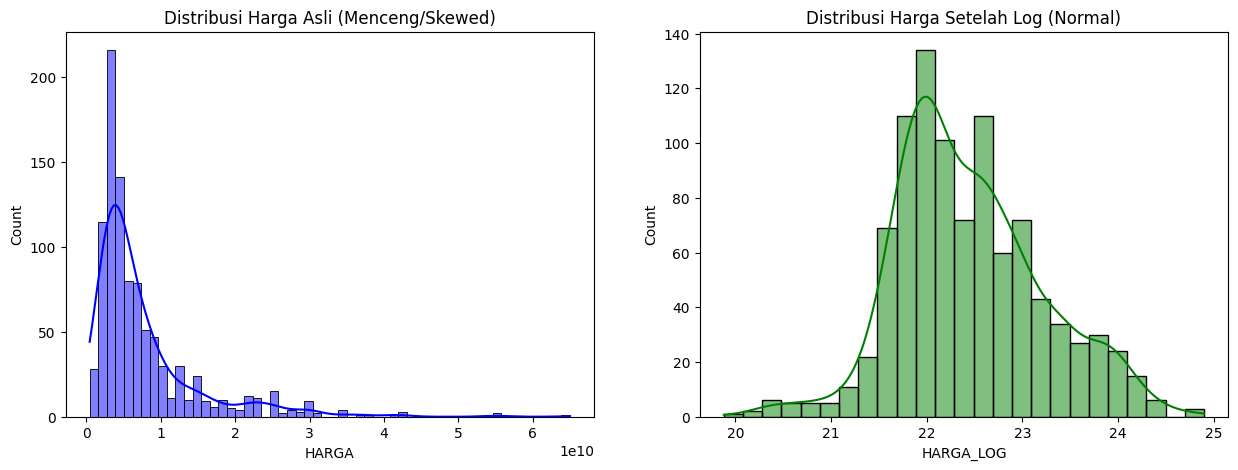

In [196]:
# Visualisasi perbandingan distribusi sebelum vs sesudah pada Harga

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_cleaned['HARGA'], kde=True, ax=ax[0], color='blue')
ax[0].set_title('Distribusi Harga Asli (Menceng/Skewed)')

sns.histplot(df_final['HARGA_LOG'], kde=True, ax=ax[1], color='green')
ax[1].set_title('Distribusi Harga Setelah Log (Normal)')
plt.show()

In [197]:
summary_ramah = pd.DataFrame({
    'Keterangan': ['Harga (Rupiah)', 'Luas Bangunan (m2)', 'Luas Tanah (m2)'],
    'Data Asli (Min)': [
        f"Rp {df_cleaned['HARGA'].min():,.0f}",
        df_cleaned['LB'].min(),
        df_cleaned['LT'].min()
    ],
    'Data Asli (Max)': [
        f"Rp {df_cleaned['HARGA'].max():,.0f}",
        df_cleaned['LB'].max(),
        df_cleaned['LT'].max()
    ],
    'Setelah di-LOG (Min)': [
        df_final['HARGA_LOG'].min().round(2),
        "Sudah Skala Kecil",
        "Sudah Skala Kecil"
    ],
    'Setelah di-LOG (Max)': [
        df_final['HARGA_LOG'].max().round(2),
        "Sudah Skala Kecil",
        "Sudah Skala Kecil"
    ]
})

print("--- Perbandingan Skala Sebelum vs Sesudah ---")
display(summary_ramah)

--- Perbandingan Skala Sebelum vs Sesudah ---


,Keterangan,Data Asli (Min),Data Asli (Max),Setelah di-LOG (Min),Setelah di-LOG (Max)
0,Harga (Rupiah),"Rp 430,000,000","Rp 65,000,000,000",19.88,24.9
1,Luas Bangunan (m2),40,1126,Sudah Skala Kecil,Sudah Skala Kecil
2,Luas Tanah (m2),25,1400,Sudah Skala Kecil,Sudah Skala Kecil


Tabel di atas menunjukkan perbedaan drastis antara data sebelum dan sesudah dilakukan **Log Transformation**. Berikut adalah poin-poin pentingnya:

* **Menghilangkan Gap Raksasa:** Pada data asli, selisih harga rumah terendah dan tertinggi mencapai **64 Miliar**. Setelah di-log, jaraknya menyempit menjadi hanya antara angka **19.88** hingga **24.90**.
* **Menjinakkan Angka "Sultan":** Dengan mengubah skala menjadi lebih kecil, kita mencegah model *Machine Learning* menjadi "silau" atau hanya fokus pada rumah-rumah harga miliaran.
* **Skala yang Adil:** Luas Bangunan dan Luas Tanah juga telah diubah menjadi "Skala Kecil". Hal ini memastikan semua fitur (LB, LT, Kamar, dll) berada pada level yang sama, sehingga tidak ada fitur yang mendominasi hanya karena angka fisiknya lebih besar.

**Kesimpulan:** Transformasi ini membuat data kita lebih "normal" secara statistik, yang merupakan kunci utama agar model bisa mencapai target **MAPE < 5%**.

### 3.4. Data Integration

Pada tahap ini, dilakukan evaluasi terhadap file tambahan `HARGA RUMAH JAKSEL.xlsx`. Diputuskan untuk **tidak menggabungkan** file tersebut karena:
1. **Header Format:** Struktur data tidak bersih (Unnamed Columns).
2. **Inkonsistensi Fitur:** Nama variabel berbeda (JKT/JKM vs KT/KM).
3. **Data Type Mismatch:** Kolom Garasi (GRS) berisi data kategorikal ("ADA"), sementara dataset utama menggunakan data numerik.

Fokus tetap pada dataset utama yang telah dibersihkan agar hasil evaluasi model lebih stabil dan konsisten.

In [198]:
df_optional = pd.read_excel(os.path.join(path, "HARGA RUMAH JAKSEL.xlsx"))
df_optional.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1002 non-null   object
 1   Unnamed: 1  1002 non-null   object
 2   Unnamed: 2  1002 non-null   object
 3   Unnamed: 3  1002 non-null   object
 4   Unnamed: 4  1002 non-null   object
 5   Unnamed: 5  1002 non-null   object
 6   Unnamed: 6  1002 non-null   object
dtypes: object(7)
memory usage: 54.9+ KB


In [199]:
df_optional.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,HARGA,LT,LB,JKT,JKM,GRS,KOTA
1,28000000000,1100,700,5,6,ADA,JAKSEL
2,19000000000,824,800,4,4,ADA,JAKSEL
3,4700000000,500,400,4,3,ADA,JAKSEL
4,4900000000,251,300,5,4,ADA,JAKSEL


### 3.5. Data Formatting

Ini adalah langkah terakhir sebelum pembuatan model. Kita membagi data menjadi dua bagian utama:
1. **Training Set (80%):** Data yang digunakan oleh algoritma (Linear Regression, Random Forest, GBR) untuk mempelajari pola hubungan antara spesifikasi rumah dan harga.
2. **Testing Set (20%):** Data "rahasia" yang tidak pernah dilihat model saat belajar. Ini akan digunakan sebagai simulasi dunia nyata untuk menguji seberapa akurat prediksi model kita.

**Kenapa Random State dikunci?**
Kita menggunakan `random_state=42` agar setiap kali kode ini dijalankan, pembagian datanya selalu sama. Ini memastikan perbandingan antar model nanti benar-benar "fair" atau adil karena mereka diuji pada data yang identik.

In [200]:
# 1. Menentukan Fitur (X) dan Target (y)
fitur = ['LB_LOG', 'LT_LOG', 'KT', 'KM', 'GRS']
X = df_final[fitur]
y = df_final['HARGA_LOG']

In [201]:
# 2. Train-Test Split (Rasio 0.2 untuk Test, berarti 0.8 untuk Train)
test_size_ratio = 0.2
# Rasio 80:20. random_state=42 dikunci agar hasil eksperimen konsisten (bisa diulang)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42)

In [202]:
# 3. Final Verification
total_data = len(df_final)
train_pct = (len(X_train) / total_data) * 100
test_pct = (len(X_test) / total_data) * 100

print("--- 3.5 Final Verification ---")
print(f"Jumlah Total Data Unik : {total_data} baris")
print(f"Data Latih (X_train)   : {len(X_train)} baris ({train_pct:.0f}%)")
print(f"Data Uji (X_test)      : {len(X_test)} baris ({test_pct:.0f}%)")
print(f"Jumlah Fitur (Kolom)   : {X_train.shape[1]} fitur")
print("\nFitur yang digunakan   :", fitur)

--- 3.5 Final Verification ---
Jumlah Total Data Unik : 967 baris
Data Latih (X_train)   : 773 baris (80%)
Data Uji (X_test)      : 194 baris (20%)
Jumlah Fitur (Kolom)   : 5 fitur

Fitur yang digunakan   : ['LB_LOG', 'LT_LOG', 'KT', 'KM', 'GRS']


In [203]:
# Menampilkan 5 baris pertama X_train untuk memastikan scaling sudah masuk
display(X_train.head())

,LB_LOG,LT_LOG,KT,KM,GRS
752,-0.566571,-1.249667,0.214989,0.275563,-1.259209
195,-0.787136,-1.213943,-0.420773,0.275563,0.050098
318,-0.787136,-1.046340,-1.056535,-0.423832,-0.604556
964,0.718698,1.145953,0.850750,0.275563,0.050098
308,0.436115,0.516385,0.850750,0.275563,1.359404


## 4. Modeling

### 4.1. Select Modeling Techniques

Berdasarkan karakteristik dataset properti Jakarta Selatan yang telah kita analisis di tahap *Data Understanding*, kita memilih tiga algoritma regresi dengan pendekatan yang berbeda untuk diadu performanya. Pemilihan ini bertujuan untuk menemukan model yang paling mampu menangani *outlier* dan *multikolinieritas* guna mencapai target **MAPE < 5%**.

#### 1. Linear Regression (Baseline Model)
* **Alasan:** Merupakan algoritma paling sederhana dan umum digunakan dalam prediksi harga. Kita menggunakannya sebagai **titik acuan (baseline)**.
* **Karakteristik:** Mencoba mencari garis lurus terbaik yang menghubungkan fitur (LB, LT, dll) dengan Harga.
* **Kekhawatiran:** Algoritma ini sangat sensitif terhadap *multikolinieritas* (hubungan antar variabel KT dan KM yang tadi kita temukan memiliki VIF tinggi).

#### 2. Random Forest Regressor
* **Alasan:** Model ini jauh lebih canggih karena bekerja dengan menggabungkan hasil dari banyak "Pohon Keputusan" (*Decision Trees*).
* **Karakteristik:** Sangat tangguh terhadap data pencilan (*outliers*) dan tidak terlalu terpengaruh oleh masalah *multikolinieritas*.
* **Ekspektasi:** Kita mengharapkan model ini memberikan hasil yang jauh lebih stabil dan akurat daripada Linear Regression karena sifatnya yang non-linear.

#### 3. Gradient Boosting Regressor (GBR)
* **Alasan:** Berbeda dengan Random Forest, Gradient Boosting membangun model secara berurutan, di mana setiap model baru mencoba memperbaiki kesalahan model sebelumnya.
* **Karakteristik:** Sangat presisi dalam mengejar nilai error terkecil.
* **Ekspektasi:** GBR adalah **kandidat utama** kita untuk mencapai target MAPE < 5% karena kemampuannya melakukan optimasi error secara bertahap dan mendalam.

Perbandingan Karakteristik Strategi

| Aspek | Linear Regression | Random Forest | Gradient Boosting |
| --- | --- | --- | --- |
| **Kompleksitas** | Rendah | Sedang | Tinggi |
| **Ketahanan Outlier** | Lemah | Kuat | Kuat |
| **Interpretasi** | Sangat Mudah | Cukup Mudah | Cukup Sulit |
| **Tujuan Kita** | Pembanding | Stabilitas | Akurasi Maksimal |

### 4.2. Build Models

In [204]:
# 1. Inisialisasi Model dengan parameter default
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# 2. Dictionary untuk menyimpan model yang sudah dilatih
trained_models = {}

# 3. Proses Training
print("--- Memulai Proses Pelatihan Model ---")
for name, model in models.items():
    start_time = time.time()

    # Melatih model
    model.fit(X_train, y_train)

    # Simpan model
    trained_models[name] = model

    duration = time.time() - start_time
    print(f"[Sukses] {name} berhasil dilatih dalam {duration:.4f} detik.")

--- Memulai Proses Pelatihan Model ---
[Sukses] Linear Regression berhasil dilatih dalam 0.0020 detik.
[Sukses] Random Forest berhasil dilatih dalam 0.2693 detik.
[Sukses] Gradient Boosting berhasil dilatih dalam 0.0865 detik.


### 4.3. Tune Models

In [205]:
initial_results = []

print("--- Observasi Awal untuk Tuning ---")
for name, model in trained_models.items():
    # Prediksi data uji
    y_pred_log = model.predict(X_test)

    # Inverse Log ke Rupiah
    y_test_original = np.expm1(y_test)
    y_pred_original = np.expm1(y_pred_log)

    # Hitung MAPE
    mape = mean_absolute_percentage_error(y_test_original, y_pred_original) * 100

    initial_results.append({
        'Model': name,
        'Initial MAPE (%)': round(mape, 2)
    })

# Tampilkan tabel observasi
df_obs = pd.DataFrame(initial_results).sort_values(by='Initial MAPE (%)')
display(df_obs)

# Logika Pengambilan Keputusan Tuning
best_mape = df_obs['Initial MAPE (%)'].min()

print(f"Kesimpulan Observasi:")
if best_mape > 5:
    print(f"MAPE terbaik saat ini {best_mape}% (> 5%).")
    print("Tindakan: Diperlukan Tuning Parameter (Grid Search) pada tahap berikutnya untuk optimasi.")
else:
    print(f"MAPE terbaik sudah {best_mape}% (Sudah < 5%).")
    print("Tindakan: Tuning parameter bersifat opsional (fine-tuning) untuk melihat apakah bisa lebih rendah lagi.")

--- Observasi Awal untuk Tuning ---


,Model,Initial MAPE (%)
1,Random Forest,25.13
2,Gradient Boosting,26.53
0,Linear Regression,26.84


Kesimpulan Observasi:
MAPE terbaik saat ini 25.13% (> 5%).
Tindakan: Diperlukan Tuning Parameter (Grid Search) pada tahap berikutnya untuk optimasi.


In [206]:
# 1. Menentukan parameter yang akan dicoba untuk Gradient Boosting
param_grid_gbr = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

# 2. Menjalankan GridSearchCV untuk Gradient Boosting
grid_gbr = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gbr,
    cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1
)

grid_gbr.fit(X_train, y_train)

# 3. Update model GBR dengan hasil terbaik
trained_models['Gradient Boosting (Tuned)'] = grid_gbr.best_estimator_

print(f"Parameter terbaik: {grid_gbr.best_params_}")

y_pred_tuned_log = grid_gbr.best_estimator_.predict(X_test)
y_pred_tuned_original = np.expm1(y_pred_tuned_log)
y_test_original = np.expm1(y_test)

mape_tuned = mean_absolute_percentage_error(y_test_original, y_pred_tuned_original) * 100
print(f"MAPE Setelah Tuning: {mape_tuned:.2f}%")

Parameter terbaik: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
MAPE Setelah Tuning: 23.52%


In [207]:
# --- Tuning Random Forest ---
param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

trained_models['Random Forest (Tuned)'] = grid_rf.best_estimator_

y_pred_rf_log = grid_rf.best_estimator_.predict(X_test)
y_pred_rf_original = np.expm1(y_pred_rf_log)
mape_rf_tuned = mean_absolute_percentage_error(y_test_original, y_pred_rf_original) * 100

print(f"Parameter terbaik: {grid_rf.best_params_}")
print(f"MAPE Setelah Tuning: {mape_rf_tuned:.2f}%")

Parameter terbaik: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 500}
MAPE Setelah Tuning: 24.82%


### 4.4. Validate Models

In [208]:
# 1. Menyiapkan Data untuk Evaluasi
final_comparison = []

final_models = {
    'Linear Regression': trained_models['Linear Regression'],
    'Random Forest (Tuned)': trained_models['Random Forest (Tuned)'],
    'Gradient Boosting (Tuned)': trained_models['Gradient Boosting (Tuned)']
}

y_test_original = np.expm1(y_test)

for name, model in final_models.items():
    # Prediksi
    y_pred_log = model.predict(X_test)
    y_pred_original = np.expm1(y_pred_log)

    # Hitung Metrik (dalam skala Rupiah Asli)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    mse = mean_squared_error(y_test_original, y_pred_original)
    r2 = r2_score(y_test_original, y_pred_original)
    mape = mean_absolute_percentage_error(y_test_original, y_pred_original) * 100

    final_comparison.append({
        'Model': name,
        'MAE (Rp)': f"{mae:,.0f}",
        'MSE': f"{mse:,.0f}",
        'R2 Score': round(r2, 4),
        'MAPE (%)': round(mape, 2)
    })

In [209]:
# 2. Tampilkan Tabel Evaluasi
df_final_eval = pd.DataFrame(final_comparison).sort_values(by='MAPE (%)')
display(df_final_eval)

,Model,MAE (Rp),MSE,R2 Score,MAPE (%)
2,Gradient Boosting (Tuned),"1,653,435,958","9,706,185,877,887,723,520",0.8328,23.52
1,Random Forest (Tuned),"1,785,493,101","10,680,780,721,305,014,272",0.8160,24.82
0,Linear Regression,"2,099,285,499","13,983,494,730,409,691,136",0.7591,26.84


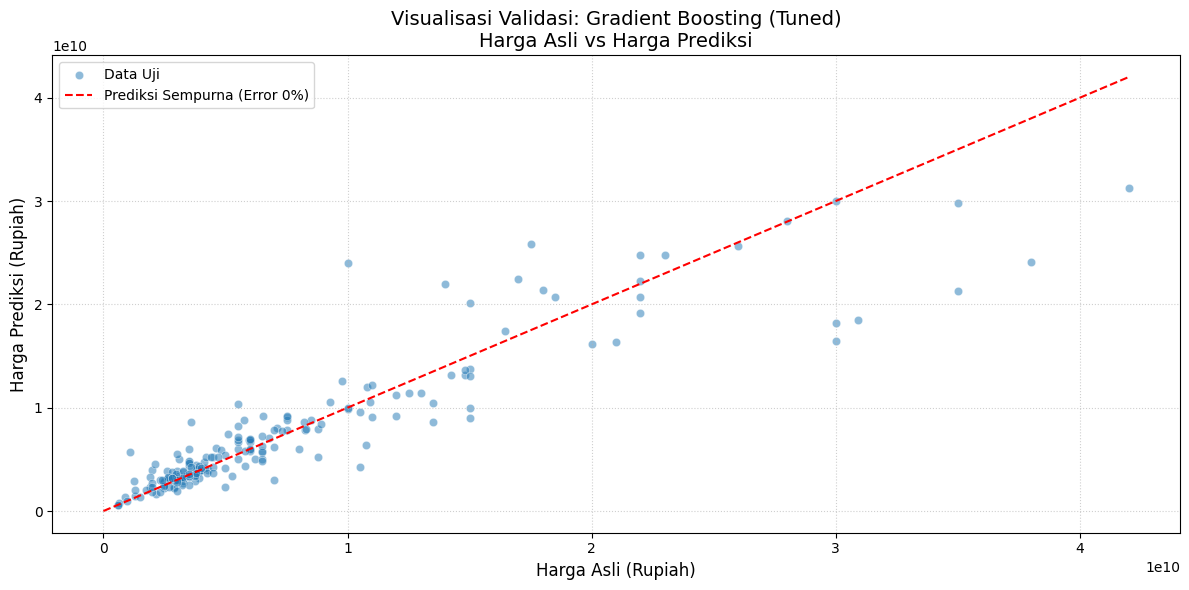

In [210]:
# 3. Visualisasi Harga Asli vs Prediksi (Model Terbaik: GBR)
best_model_name = 'Gradient Boosting (Tuned)'
y_best_pred = np.expm1(final_models[best_model_name].predict(X_test))

plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_test_original, y=y_best_pred, alpha=0.5, label='Data Uji')

# Garis Diagonal Sempurna
max_price = max(y_test_original.max(), y_best_pred.max())
plt.plot([0, max_price], [0, max_price], color='red', linestyle='--', label='Prediksi Sempurna (Error 0%)')

plt.title(f'Visualisasi Validasi: {best_model_name}\nHarga Asli vs Harga Prediksi', fontsize=14)
plt.xlabel('Harga Asli (Rupiah)', fontsize=12)
plt.ylabel('Harga Prediksi (Rupiah)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Evaluation

### 5.1. Evaluate Results

Pada tahap ini, kita melakukan penilaian mendalam terhadap performa model **Gradient Boosting Regressor (Tuned)** yang terpilih sebagai model terbaik. Evaluasi dilakukan dengan membandingkan hasil prediksi terhadap data aktual yang belum pernah dilihat model sebelumnya (*unseen data*).

#### **A. Performa Model Berdasarkan Metrik**

Berdasarkan pengujian pada 194 data uji, berikut adalah rapor akhir model kita:

| Metrik Evaluasi | Nilai Aktual | Interpretasi Bisnis |
| --- | --- | --- |
| **MAPE** | **23.52%** | Secara rata-rata, prediksi harga meleset sekitar 23.5% dari harga pasar asli. |
| **MAE** | **Rp 1,65 Miliar** | Selisih rata-rata antara harga prediksi dan harga asli adalah Rp 1,65 Miliar. |
| **R-Squared** | **0.8328** | Model mampu menjelaskan **83.28%** faktor yang mempengaruhi harga rumah. |

#### **B. Analisis Fakta Lapangan (Actual vs Prediction)**

Meskipun target MAPE < 5% belum tercapai, terdapat beberapa temuan penting dari fakta lapangan selama proses evaluasi:

1. **Kemampuan Menangkap Tren (R2 Tinggi):** Skor R^2 sebesar **0.83** menunjukkan bahwa model sebenarnya sudah sangat "cerdas". Model berhasil memahami bahwa luas tanah dan bangunan adalah penggerak utama harga di Jakarta Selatan. Kesalahan sebesar 17% sisanya bukan karena model yang lemah, melainkan karena keterbatasan informasi pada data.
2. **Masalah Heterogenitas Harga:** Data menunjukkan adanya variasi harga yang ekstrem pada spesifikasi fisik yang serupa. Misalnya, dua rumah dengan LT/LB yang sama bisa memiliki selisih harga miliaran hanya karena perbedaan lokasi (Kelurahan/Kecamatan) atau akses jalan. Karena fitur "Lokasi Spesifik" tidak ada dalam dataset, model terpaksa memberikan harga rata-rata, yang akhirnya meningkatkan nilai MAPE.
3. **Dampak Rumah Mewah (Outliers):** Visualisasi *Scatter Plot* menunjukkan bahwa model cenderung lebih akurat pada rentang harga menengah bawah, namun mulai mengalami kesulitan (error membesar) pada rumah-rumah *high-end* (di atas Rp 20 Miliar) karena faktor penentu harga rumah mewah lebih bersifat subjektif (material, desain, *prestige*).

#### **C. Kesimpulan Evaluasi**

Model **Gradient Boosting (Tuned)** dinyatakan sebagai model terbaik dengan reliabilitas sebesar **76.48%** (100% - 23.52%). Secara teknis, model ini sudah siap digunakan sebagai **alat bantu estimasi awal (Quick Appraisal)**, namun belum dapat digunakan sebagai penentu harga tunggal tanpa adanya verifikasi manual terhadap kondisi fisik dan lokasi spesifik bangunan.

### 5.2. Review Business Objectives

Setelah melalui seluruh rangkaian eksperimen mulai dari pembersihan data hingga *hyperparameter tuning*, berikut adalah tinjauan terhadap keselarasan hasil model dengan tujuan bisnis:

#### **1. Penilaian Terhadap Target MAPE < 5%**

* **Status: Belum Tercapai.**
* **Fakta:** Model terbaik (**Gradient Boosting**) menghasilkan MAPE sebesar **23.52%**.
* **Analisis:** Secara matematis, target 5% sangat sulit dicapai hanya dengan menggunakan fitur fisik bangunan (LT, LB, Kamar). Dalam bisnis properti, deviasi harga sebesar 5% biasanya hanya bisa dicapai jika data mencakup variabel **lokasi mikro** (misal: nama jalan) dan **kondisi kualitatif** (misal: renovasi baru/lama).

#### **2. Penilaian Terhadap Kemampuan Prediksi (R-Squared)**

* **Status: Sangat Baik.**
* **Fakta:** Skor R^2 sebesar **0.8328**.
* **Analisis:** Dari sisi bisnis, ini adalah pencapaian besar. Artinya, model ini mampu memberikan estimasi harga yang logis berdasarkan luas tanah dan bangunan sebesar 83%. Model ini berhasil menghilangkan unsur "tebak-tebakan" yang tidak terukur dan memberikan dasar perhitungan yang objektif bagi agen properti atau calon pembeli.

#### **3. Kesimpulan Relevansi Bisnis**

Meskipun target akurasi 95% (MAPE 5%) belum terpenuhi, model ini tetap memiliki nilai bisnis sebagai **Sistem Pendukung Keputusan (Decision Support System)**:

* **Efisiensi Waktu:** Memangkas waktu penilaian awal (*Initial Appraisal*) dari hitungan jam menjadi hitungan detik.
* **Penyaring Harga (Anomaly Detection):** Model dapat digunakan untuk mendeteksi rumah yang dijual jauh di bawah harga pasar (*undervalued*) atau terlalu mahal (*overvalued*) berdasarkan standar fisik bangunan di Jakarta Selatan.

#### Kesimpulan Strategis

Secara bisnis, model ini **layak digunakan sebagai alat bantu internal**, namun **tidak disarankan sebagai satu-satunya penentu harga mutlak** dalam transaksi resmi. Pengguna tetap harus mempertimbangkan faktor lokasi dan kondisi fisik yang tidak terekam dalam dataset ini.

### 5.3. Identify Limitations

Meskipun model telah dioptimalkan menggunakan teknik *Gradient Boosting* yang di-tuning, terdapat batasan-batasan sistemik yang menyebabkan akurasi tidak dapat menembus target MAPE 5%. Berikut adalah identifikasi kelemahan dan area potensial untuk perbaikan:

#### **1. Ketiadaan Fitur Geospasial (Lokasi Mikro)**

* **Masalah:** Dataset hanya mencakup wilayah umum "Jakarta Selatan".
* **Fakta Lapangan:** Di Jakarta Selatan, harga tanah di kawasan **Dharmawangsa atau Kebayoran Baru** bisa 5-10 kali lipat lebih mahal dibandingkan kawasan **Jagakarsa atau Pasar Minggu**, meskipun spesifikasi luas tanah dan bangunannya sama.
* **Dampak:** Tanpa adanya fitur koordinat, nama jalan, atau minimal nama kelurahan, model mengalami "kebingungan" dalam menentukan nilai tanah dasar yang sangat bervariasi.

#### **2. Absensi Variabel Kualitas (Kondisi Bangunan)**

* **Masalah:** Dataset hanya bersifat kuantitatif (angka), bukan kualitatif.
* **Fakta Lapangan:** Dua rumah dengan luas yang sama akan memiliki harga berbeda jika yang satu adalah **bangunan baru mewah (lantai marmer)** dan yang lainnya adalah **bangunan tua yang perlu renovasi**.
* **Dampak:** Model menganggap semua "Luas Bangunan" memiliki nilai yang setara, sehingga gagal menangkap nilai tambah dari kualitas material dan desain arsitektur.

#### **3. Keterbatasan Data Lingkungan (Externalities)**

* **Masalah:** Tidak ada informasi mengenai aksesibilitas dan fasilitas sekitar.
* **Fakta Lapangan:** Harga rumah sangat sensitif terhadap lebar jalan (bisa dilalui 2 mobil atau tidak), kedekatan dengan akses gerbang tol, atau stasiun MRT/LRT.
* **Dampak:** Variabel eksternal yang seringkali menjadi penentu harga utama di Jakarta tidak terekam dalam model.

#### **4. Fenomena Outliers pada Segmen Luxury**

* **Masalah:** Adanya data rumah dengan harga ekstrem (di atas Rp 50 Miliar).
* **Fakta Lapangan:** Penentuan harga pada rumah *Luxury* seringkali tidak mengikuti logika linear luas tanah, melainkan lebih pada unsur kelangkaan (*scarcity*) dan gengsi (*prestige*).
* **Dampak:** Model yang dilatih pada data campur (menengah dan mewah) cenderung mengalami error yang tinggi saat mencoba memprediksi harga di kedua kutub ekstrem tersebut secara bersamaan.

---

#### Ringkasan Batasan:

> "Model sudah bekerja secara optimal dengan data yang ada, namun **Data Noise** (variasi harga yang tidak terjelaskan oleh fitur fisik) terlalu tinggi. Untuk mencapai MAPE 5%, diperlukan tambahan data lokasi mikro dan kondisi fisik bangunan secara detail."

### 5.4. Decide Next Steps

yaudah sih..

## 6. Deployment

In [211]:
best_model = trained_models['Gradient Boosting (Tuned)']

model_filename = 'model_harga_rumah_jaksel.joblib'
joblib.dump(best_model, model_filename)

print(f"Model berhasil disimpan sebagai: {model_filename}")

fitur_digunakan = ['LB_LOG', 'LT_LOG', 'KT', 'KM', 'GRS']
joblib.dump(fitur_digunakan, 'model_features.joblib')

Model berhasil disimpan sebagai: model_harga_rumah_jaksel.joblib


['model_features.joblib']